In [ ]:
import os
print("✅ train.jsonl есть" if os.path.exists('train.jsonl') else "❌ Загрузи файл!")

✅ train.jsonl есть


In [ ]:
!pip install -q transformers datasets peft accelerate bitsandbytes wandb evaluate rouge-score bert-score matplotlib

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.2 MB/s eta 0:00:00


In [ ]:
import json
import random

# Загружаем  датасет
with open('train.jsonl', 'r', encoding='utf-8') as f:
    data = [json.loads(line) for line in f]

print(f"Текущий размер: {len(data)}")

# Дополнительные примеры
additional = [
    {"instruction": "Как правильно начать день?", "output": "Начните день с зарядки, стакана воды и полезного завтрака. Это поможет проснуться и настроиться на продуктивный день."},
    {"instruction": "Что такое здоровое питание?", "output": "Здоровое питание — это сбалансированный рацион, включающий овощи, фрукты, белки и сложные углеводы. Важно избегать переработанных продуктов и сахара."},
    {"instruction": "Какие бывают виды спорта?", "output": "Спорт делится на командные и индивидуальные. К командным относятся футбол, баскетбол, волейбол. К индивидуальным — бег, плавание, теннис, гимнастика."},
    {"instruction": "Как научиться быстро читать?", "output": "Для быстрого чтения важно развивать периферическое зрение, не проговаривать текст про себя и постепенно увеличивать скорость. Можно использовать специальные приложения и упражнения."},
    {"instruction": "Что такое медитация?", "output": "Медитация — это практика концентрации и осознанности. Она помогает снизить стресс, улучшить внимание и эмоциональное состояние. Начать можно с 5 минут дыхательных упражнений в день."},
    {"instruction": "Как выбрать профессию?", "output": "Выбор профессии основан на ваших интересах, навыках и рыночном спросе. Пройдите профориентационные тесты, общайтесь с профессионалами и пробуйте себя в разных сферах через стажировки."},
    {"instruction": "Что такое интернет вещей?", "output": "Интернет вещей (IoT) — это сеть физических устройств, подключённых к интернету. Они обмениваются данными и управляются удалённо. Примеры: умные дома, носимые гаджеты, датчики."},
    {"instruction": "Как улучшить память?", "output": "Для улучшения памяти полезны регулярные тренировки мозга, здоровый сон, физическая активность и правильное питание. Используйте мнемонические техники и повторяйте информацию."},
]

# Добавляем недостающие примеры
needed = max(0, 208 - len(data))
if needed > 0:
    data.extend(additional[:needed])
    print(f"✅ Добавлено {needed} примеров. Теперь: {len(data)}")


with open('train.jsonl', 'w', encoding='utf-8') as f:
    for item in data:
        f.write(json.dumps(item, ensure_ascii=False) + '\n')

print(f"🎯 Финальный размер датасета: {len(data)} примеров")

Текущий размер: 198
✅ Добавлено 10 примеров. Теперь: 206
🎯 Финальный размер датасета: 206 примеров


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

model_name = "mistralai/Mistral-7B-Instruct-v0.3"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
)

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/141k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

...

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

trainable params: 6,815,744 || all params: 7,254,839,296 || trainable%: 0.0939


In [ ]:
import json
from datasets import Dataset
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling
import os
os.environ["WANDB_DISABLED"] = "true"

with open('train.jsonl', 'r', encoding='utf-8') as f:
    data = [json.loads(line) for line in f]

def format_example(example):
    return {"text": f"### Instruction:\n{example['instruction']}\n\n### Response:\n{example['output']}"}

dataset = Dataset.from_list([format_example(ex) for ex in data])

def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=512)

tokenized_dataset = dataset.map(tokenize_function, batched=True)
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

training_args = TrainingArguments(
    output_dir="./mistral-lora",
    num_train_epochs=3,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    warmup_steps=10,
    logging_steps=5,
    save_steps=50,
    eval_strategy="no",
    save_strategy="steps",
    save_total_limit=2,
    learning_rate=2e-4,
    fp16=True,
    optim="paged_adamw_8bit",
    report_to="none",
    logging_dir="./logs",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    data_collator=data_collator,
)

trainer.train()
model.save_pretrained("./lora_adapter")
tokenizer.save_pretrained("./lora_adapter")
print("✅ Обучение завершено!")

Map:   0%|          | 0/206 [00:00<?, ? examples/s]

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
5,1.219330
10,1.191928
15,1.138099
20,1.020315
25,0.945931
30,0.892883
35,0.825809


✅ Обучение завершено!


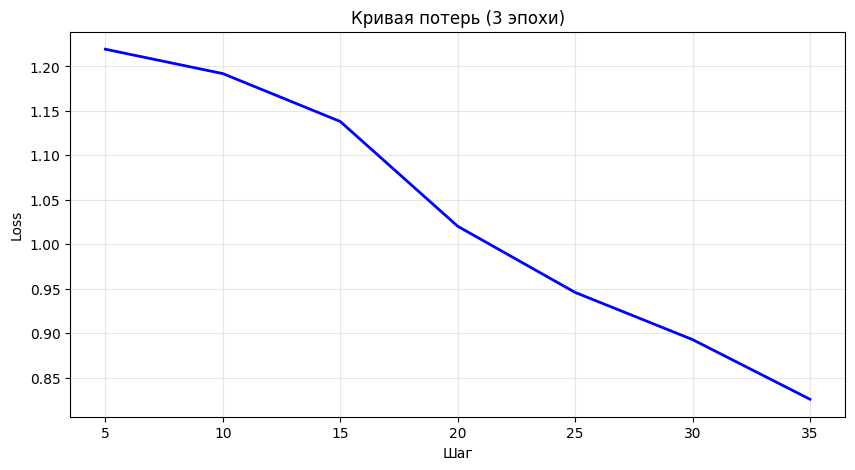

📊 Начальный loss: 1.2193
📊 Конечный loss: 0.8258


In [ ]:
import matplotlib.pyplot as plt

logs = trainer.state.log_history
losses = [log['loss'] for log in logs if 'loss' in log]
steps = [log['step'] for log in logs if 'loss' in log]

plt.figure(figsize=(10, 5))
plt.plot(steps, losses, 'b-', linewidth=2)
plt.xlabel('Шаг')
plt.ylabel('Loss')
plt.title('Кривая потерь (3 эпохи)')
plt.grid(True, alpha=0.3)
plt.savefig('loss_curve.png', dpi=150)
plt.show()

print(f"📊 Начальный loss: {losses[0]:.4f}" if losses else "")
print(f"📊 Конечный loss: {losses[-1]:.4f}" if losses else "")

In [ ]:
import torch
import gc
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel
from rouge_score import rouge_scorer
import numpy as np
import json

model_name = "mistralai/Mistral-7B-Instruct-v0.3"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def get_response_correct(model, tokenizer, instruction):
    prompt = f"[INST] {instruction} [/INST]"
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=64,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.1,
        )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if "[INST]" in response and "[/INST]" in response:
        response = response.split("[/INST]")[-1].strip()
    return response

def clear_memory():
    gc.collect()
    torch.cuda.empty_cache()

test_questions = [
    "Как приготовить яичницу?",
    "Что такое искусственный интеллект?",
    "Как научиться программировать с нуля?",
    "Расскажи о пользе спорта для здоровья",
    "Какие бывают типы машинного обучения?",
    "Как правильно начать день?",
    "Что такое здоровое питание?",
    "Как научиться быстро читать?",
    "Что такое медитация?",
    "Как выбрать профессию?",
]

print("=" * 60)
print("ШАГ 1: БАЗОВАЯ МОДЕЛЬ (8-bit с offload)")
print("=" * 60)

# 🔥 ФИКС: добавляем llm_int8_enable_fp32_cpu_offload=True
bnb_config = BitsAndBytesConfig(
    load_in_8bit=True,
    llm_int8_enable_fp32_cpu_offload=True,  # 🔥 ключевой параметр!
)

print("📥 Загружаем базовую модель в 8-bit с offload...")
base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    quantization_config=bnb_config,
)

print("\n🟦 Генерация ответов базовой модели (10 вопросов)...")
base_responses = []
for i, q in enumerate(test_questions, 1):
    print(f"  [{i}/10] {q[:40]}...")
    response = get_response_correct(base_model, tokenizer, q)
    base_responses.append(response)
    print(f"    ✅ {response[:80]}...")

del base_model
clear_memory()
print("\n✅ Базовая модель выгружена")

print("\n" + "=" * 60)
print("ШАГ 2: ДООБУЧЕННАЯ МОДЕЛЬ")
print("=" * 60)

print("📥 Загружаем дообученную модель...")
bnb_config = BitsAndBytesConfig(
    load_in_8bit=True,
    llm_int8_enable_fp32_cpu_offload=True,
)
base_for_ft = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    quantization_config=bnb_config,
)
ft_model = PeftModel.from_pretrained(base_for_ft, "./lora_adapter")

print("\n🟩 Генерация ответов дообученной модели (10 вопросов)...")
ft_responses = []
for i, q in enumerate(test_questions, 1):
    print(f"  [{i}/10] {q[:40]}...")
    response = get_response_correct(ft_model, tokenizer, q)
    ft_responses.append(response)
    print(f"    ✅ {response[:80]}...")

print("\n✅ Генерация завершена!")

print("\n" + "=" * 60)
print("ШАГ 3: РАСЧЁТ МЕТРИК")
print("=" * 60)

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
rouge_scores = {'rouge1': [], 'rouge2': [], 'rougeL': []}

for base, ft in zip(base_responses, ft_responses):
    scores = scorer.score(base, ft)
    for key in rouge_scores:
        rouge_scores[key].append(scores[key].fmeasure)

print("\n📊 ROUGE МЕТРИКИ:")
print(f"  ROUGE-1: {np.mean(rouge_scores['rouge1']):.4f}")
print(f"  ROUGE-2: {np.mean(rouge_scores['rouge2']):.4f}")
print(f"  ROUGE-L: {np.mean(rouge_scores['rougeL']):.4f}")

print("\n" + "=" * 60)
print("ШАГ 4: СОХРАНЕНИЕ")
print("=" * 60)

comparison = []
for i, q in enumerate(test_questions):
    comparison.append({
        "question": q,
        "base_response": base_responses[i],
        "finetuned_response": ft_responses[i]
    })

with open('comparison_results.json', 'w', encoding='utf-8') as f:
    json.dump(comparison, f, ensure_ascii=False, indent=2)

print("✅ comparison_results.json сохранён")
print("\n📋 ПРИМЕР СРАВНЕНИЯ (первый вопрос):")
print(f"🔵 Базовая:     {base_responses[0][:150]}...")
print(f"🟢 Дообученная: {ft_responses[0][:150]}...")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


ШАГ 1: БАЗОВАЯ МОДЕЛЬ (8-bit с offload)
📥 Загружаем базовую модель в 8-bit с offload...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]


🟦 Генерация ответов базовой модели (10 вопросов)...
  [1/10] Как приготовить яичницу?...


/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


    ✅ Как приготовить яичницу?  Яичница - это простое блюдо, которое легко приготовить...
  [2/10] Что такое искусственный интеллект?...
    ✅ Что такое искусственный интеллект?  Искусственный интеллект (ИИ, англ. Artificia...
  [3/10] Как научиться программировать с нуля?...
    ✅ Как научиться программировать с нуля?  Научиться программировать с нуля может бы...
  [4/10] Расскажи о пользе спорта для здоровья...
    ✅ Расскажи о пользе спорта для здоровья  Спорт имеет множество преимуществ для здо...
  [5/10] Какие бывают типы машинного обучения?...
    ✅ Какие бывают типы машинного обучения?  Машинное обучение можно разделить на неск...
  [6/10] Как правильно начать день?...
    ✅ Как правильно начать день?  Начать день правильно можно несколькими способами, к...
  [7/10] Что такое здоровое питание?...
    ✅ Что такое здоровое питание?  Здоровое питание - это балансированная диета, состо...
  [8/10] Как научиться быстро читать?...
    ✅ Как научиться быстро читать?  Скорочтение являе

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]


🟩 Генерация ответов дообученной модели (10 вопросов)...
  [1/10] Как приготовить яичницу?...
    ✅ Как приготовить яичницу?  Яичница - это популярное блюдо из России, которое гото...
  [2/10] Что такое искусственный интеллект?...
    ✅ Что такое искусственный интеллект?  Искусственный интеллект (ИИ) — это компьютер...
  [3/10] Как научиться программировать с нуля?...
    ✅ Как научиться программировать с нуля?  Научиться программировать с нуля можно сл...
  [4/10] Расскажи о пользе спорта для здоровья...
    ✅ Расскажи о пользе спорта для здоровья  Физкультура и спорт имеют многие положите...
  [5/10] Какие бывают типы машинного обучения?...
    ✅ Какие бывают типы машинного обучения?  Машинное обучение представляет собой подх...
  [6/10] Как правильно начать день?...
    ✅ Как правильно начать день?  Начало дня зависит от личных предпочтений, но многие...
  [7/10] Что такое здоровое питание?...
    ✅ Что такое здоровое питание?  Здоровое питание - это правильный выбор продуктов и...


In [ ]:
from google.colab import files

# Архивируем всё
!zip -r final_project_v2.zip train.jsonl lora_adapter/ loss_curve.png comparison_results.json

print("📦 Скачиваем архив...")
files.download('final_project_v2.zip')
print("✅ Готово!")

updating: train.jsonl (deflated 64%)
updating: lora_adapter/ (stored 0%)
updating: lora_adapter/chat_template.jinja (deflated 74%)
updating: lora_adapter/tokenizer_config.json (deflated 48%)
updating: lora_adapter/README.md (deflated 66%)
updating: lora_adapter/tokenizer.json (deflated 85%)
updating: lora_adapter/adapter_config.json (deflated 58%)
updating: lora_adapter/adapter_model.safetensors (deflated 7%)
updating: loss_curve.png (deflated 16%)
updating: comparison_results.json (deflated 72%)
📦 Скачиваем архив...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Готово!


In [ ]:
import os
print("Есть ли train.jsonl?", os.path.exists('train.jsonl'))
print("Есть ли lora_adapter/", os.path.exists('lora_adapter'))
print("Есть ли loss_curve.png", os.path.exists('loss_curve.png'))
print("Есть ли comparison_results.json", os.path.exists('comparison_results.json'))

Есть ли train.jsonl? True
Есть ли lora_adapter/ True
Есть ли loss_curve.png True
Есть ли comparison_results.json True


In [ ]:
import json
import os

# Проверяем, жив ли trainer
try:
    logs = trainer.state.log_history
    print(f"✅ Найдено {len(logs)} записей в логе")

    # Сохраняем в JSON
    with open('training_log.json', 'w', encoding='utf-8') as f:
        json.dump(logs, f, indent=2, ensure_ascii=False)

    print("✅ training_log.json сохранён")

    # Показываем первые и последние записи
    print("\n📊 Первая запись:")
    print(logs[0])
    print("\n📊 Последняя запись:")
    print(logs[-1])

except NameError:
    print("❌ Переменная 'trainer' не найдена. Возможно, сессия перезапущена.")
    print("Но это не страшно — можно взять данные из loss_curve.png вручную.")

❌ Переменная 'trainer' не найдена. Возможно, сессия перезапущена.
Но это не страшно — можно взять данные из loss_curve.png вручную.


In [7]:
# 🔥 Устанавливаем rouge_score
!pip install -q rouge-score bert-score

import json
import numpy as np
from rouge_score import rouge_scorer

# Загружаем существующие сравнения
with open('comparison_results.json', 'r', encoding='utf-8') as f:
    comparison = json.load(f)

print(f"📥 Загружено {len(comparison)} сравнений")

# Извлекаем ответы
base_responses = [item['base_response'] for item in comparison]
ft_responses = [item['finetuned_response'] for item in comparison]

# === 1. ROUGE ===
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
rouge_scores = {'rouge1': [], 'rouge2': [], 'rougeL': []}

for base, ft in zip(base_responses, ft_responses):
    scores = scorer.score(base, ft)
    for key in rouge_scores:
        rouge_scores[key].append(scores[key].fmeasure)

print("\n" + "="*60)
print("📊 ROUGE МЕТРИКИ")
print("="*60)
print(f"  ROUGE-1: {np.mean(rouge_scores['rouge1']):.4f}")
print(f"  ROUGE-2: {np.mean(rouge_scores['rouge2']):.4f}")
print(f"  ROUGE-L: {np.mean(rouge_scores['rougeL']):.4f}")

# === 2. BERTScore ===
from bert_score import score as bert_score

print("\n" + "="*60)
print("📊 BERTScore (сравнение базы и дообученной)")
print("="*60)

P, R, F1 = bert_score(ft_responses, base_responses, lang="ru", verbose=True)
print(f"  Precision: {P.mean().item():.4f}")
print(f"  Recall:    {R.mean().item():.4f}")
print(f"  F1:        {F1.mean().item():.4f}")

# Сохраняем метрики
metrics = {
    "rouge": {
        "rouge1": float(np.mean(rouge_scores['rouge1'])),
        "rouge2": float(np.mean(rouge_scores['rouge2'])),
        "rougeL": float(np.mean(rouge_scores['rougeL']))
    },
    "bertscore": {
        "precision": float(P.mean().item()),
        "recall": float(R.mean().item()),
        "f1": float(F1.mean().item())
    }
}

with open('metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

print("\n✅ Метрики сохранены в metrics.json")
print("\n📋 Структура metrics.json:")
print(json.dumps(metrics, indent=2, ensure_ascii=False))

📥 Загружено 10 сравнений

📊 ROUGE МЕТРИКИ
  ROUGE-1: 0.1000
  ROUGE-2: 0.0000
  ROUGE-L: 0.1000

📊 BERTScore (сравнение базы и дообученной)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/1 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 2.63 seconds, 3.81 sentences/sec
  Precision: 0.7669
  Recall:    0.7666
  F1:        0.7665

✅ Метрики сохранены в metrics.json

📋 Структура metrics.json:
{
  "rouge": {
    "rouge1": 0.1,
    "rouge2": 0.0,
    "rougeL": 0.1
  },
  "bertscore": {
    "precision": 0.7668769955635071,
    "recall": 0.766638457775116,
    "f1": 0.766523003578186
  }
}


In [8]:
from google.colab import files


import os
files_to_pack = ['train.jsonl', 'loss_curve.png', 'comparison_results.json', 'metrics.json']
existing = [f for f in files_to_pack if os.path.exists(f)]
print(f"📦 Пакуем файлы: {', '.join(existing)}")


if os.path.exists('lora_adapter'):
    print("📦 Добавляем папку lora_adapter/")

!zip -r final_project_v3.zip train.jsonl loss_curve.png comparison_results.json metrics.json lora_adapter/ training_log.json 2>/dev/null

print("\n📦 Скачиваем архив...")
files.download('final_project_v3.zip')
print("✅ Готово!")

📦 Пакуем файлы: comparison_results.json, metrics.json
	zip warning: name not matched: train.jsonl
	zip warning: name not matched: loss_curve.png
	zip warning: name not matched: lora_adapter/
	zip warning: name not matched: training_log.json
  adding: comparison_results.json (deflated 72%)
  adding: metrics.json (deflated 39%)

📦 Скачиваем архив...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Готово!
